In [1]:
import sys
import os

# Adjust the path below if your notebook lives under src/examples:
# we need the parent of "src" in sys.path so that "import vitalnodes" works.
repo_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir, os.pardir))
# e.g. if cwd = ".../src/examples", repo_root becomes ".../"
sys.path.insert(0, os.path.join(repo_root, "src"))

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
from vitalnodes.orchestrator import compute_metric, compute_metrics, get_metric_names

## Network definition

In [3]:
# Example usage with the provided snapshots
G0 = nx.Graph()
for i in range(5):
    G0.add_node(i)
G0.add_edge(0, 1)
G0.add_edge(3, 4)

G1 = nx.Graph()
for i in range(5):
    G1.add_node(i)
G1.add_edge(1, 2)
G1.add_edge(3, 4)

G2 = nx.Graph()
for i in range(5):
    G2.add_node(i)
G2.add_edge(0, 1)
G2.add_edge(0, 2)
G2.add_edge(2, 3)

G3 = nx.Graph()
for i in range(5):
    G3.add_node(i)
G3.add_edge(2, 3)

snapshots = [G0, G1, G2, G3]

custom_positions = {
    0: (1, 0.6),
    1: (1.8, 1/2),
    2: (3/2, 0.4),
    3: (1/2, 0.4),
    4: (0.2, 1/2)
}

#### Network Visualization

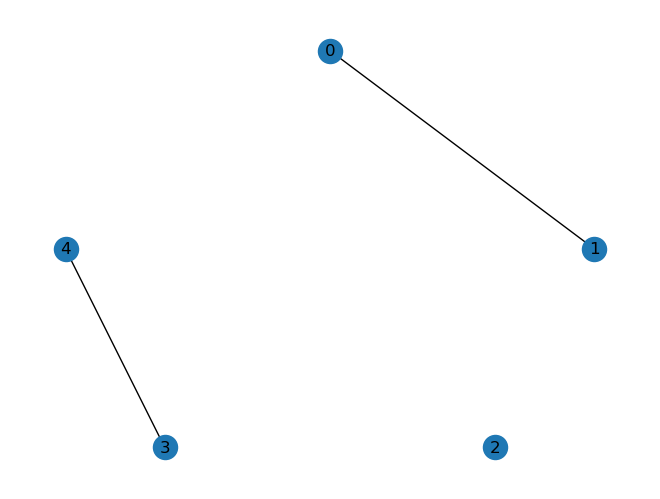

In [4]:
nx.draw(G0, pos=custom_positions, with_labels=True)  # Visualize the first snapshot

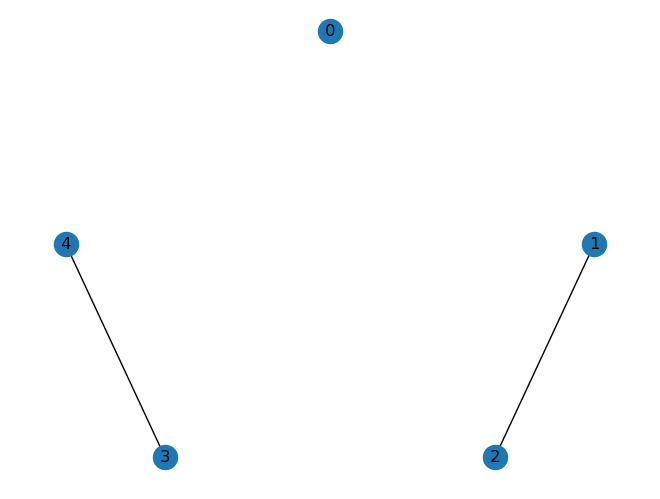

In [5]:
nx.draw(G1, pos=custom_positions, with_labels=True)  # Visualize the second snapshot

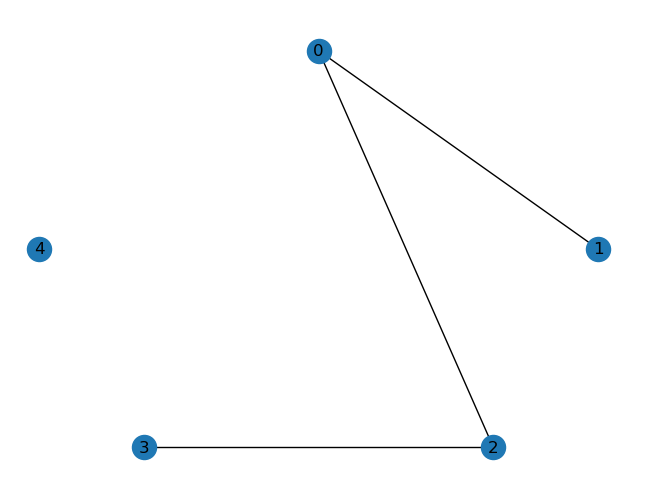

In [6]:
nx.draw(G2, pos=custom_positions, with_labels=True)  # Visualize the third snapshot

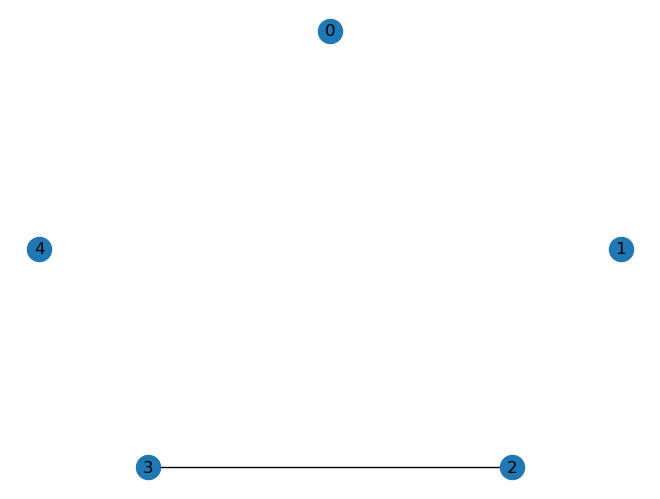

In [7]:
nx.draw(G3, pos=custom_positions, with_labels=True)  # Visualize the fourth snapshot

#### Network centrality measures

In [8]:
igc_over_time = compute_metric(snapshots, "igc")
print("IGC over time:", igc_over_time)

average_igc_over_time = {
    node: sum([igc_over_time[i][node] for i in range(len(igc_over_time))]) / len(igc_over_time)
    for node in snapshots[0].nodes()
}
print("Average IGC:", average_igc_over_time)

IGC over time: [{0: 1.0, 1: 1.0, 2: 0.0, 3: 1.0, 4: 1.0}, {0: 0.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0}, {0: 3.25, 1: 2.611111111111111, 2: 3.25, 3: 2.611111111111111, 4: 0.0}, {0: 0.0, 1: 0.0, 2: 1.0, 3: 1.0, 4: 0.0}]
Average IGC: {0: 1.0625, 1: 1.1527777777777777, 2: 1.3125, 3: 1.4027777777777777, 4: 0.5}


In [9]:
tgc = compute_metric(snapshots, "tgc")
print("TGC:", tgc)

TGC: {0: 0.6875, 1: 0.6875, 2: 1.125, 3: 0.5, 4: 0.171875}


In [10]:
metrics_over_time = compute_metrics(snapshots, ["igc", "dk", "ecrm", "ninl", "cld", "gli", "h_index", "ls"])
print("Metrics over time:", metrics_over_time)

Graph at index 0 is not connected; skipping avg_shortest_path and metrics based on it (['ninl', 'ninl_layer0'])
Graph at index 1 is not connected; skipping avg_shortest_path and metrics based on it (['ninl', 'ninl_layer0'])
Graph at index 2 is not connected; skipping avg_shortest_path and metrics based on it (['ninl', 'ninl_layer0'])
Graph at index 3 is not connected; skipping avg_shortest_path and metrics based on it (['ninl', 'ninl_layer0'])


Metrics over time: {0: {'igc': {0: 1.0, 1: 1.0, 2: 0.0, 3: 1.0, 4: 1.0}, 'dk': {0: 9.0, 1: 9.0, 2: 0.0, 3: 9.0, 4: 9.0}, 'ecrm': {0: 5.0, 1: 5.0, 2: 0.0, 3: 5.0, 4: 5.0}, 'ninl': {0: None, 1: None, 2: None, 3: None, 4: None}, 'cld': {0: 1.0, 1: 1.0, 2: 0.0, 3: 1.0, 4: 1.0}, 'gli': {0: 3.716929792624134, 1: 3.716929792624134, 2: 0.0, 3: 3.716929792624134, 4: 3.716929792624134}, 'h_index': {0: 1, 1: 1, 2: 0, 3: 1, 4: 1}, 'ls': {0: 1.0, 1: 1.0, 2: 0.0, 3: 1.0, 4: 1.0}}, 1: {'igc': {0: 0.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0}, 'dk': {0: 0.0, 1: 9.0, 2: 9.0, 3: 9.0, 4: 9.0}, 'ecrm': {0: 0.0, 1: 5.0, 2: 5.0, 3: 5.0, 4: 5.0}, 'ninl': {0: None, 1: None, 2: None, 3: None, 4: None}, 'cld': {0: 0.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0}, 'gli': {0: 0.0, 1: 3.716929792624134, 2: 3.716929792624134, 3: 3.716929792624134, 4: 3.716929792624134}, 'h_index': {0: 0, 1: 1, 2: 1, 3: 1, 4: 1}, 'ls': {0: 0.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0}}, 2: {'igc': {0: 3.25, 1: 2.611111111111111, 2: 3.25, 3: 2.611111111111111, 4:

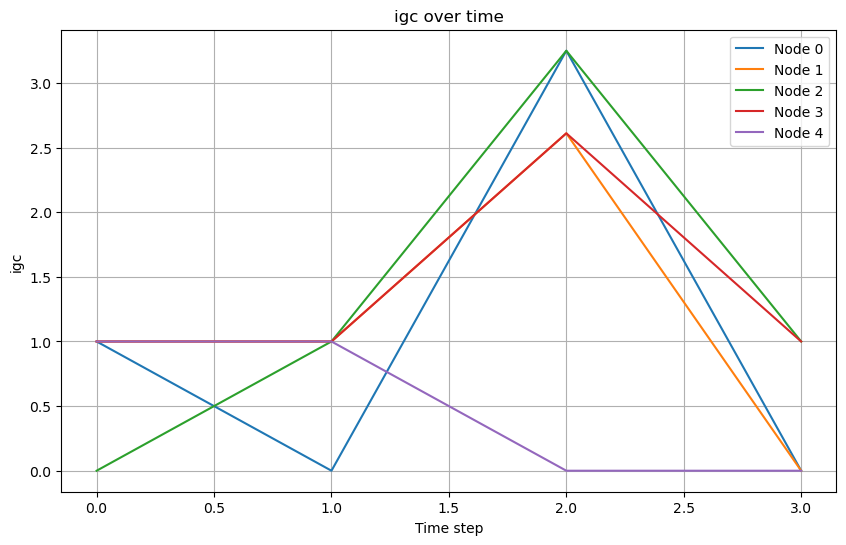

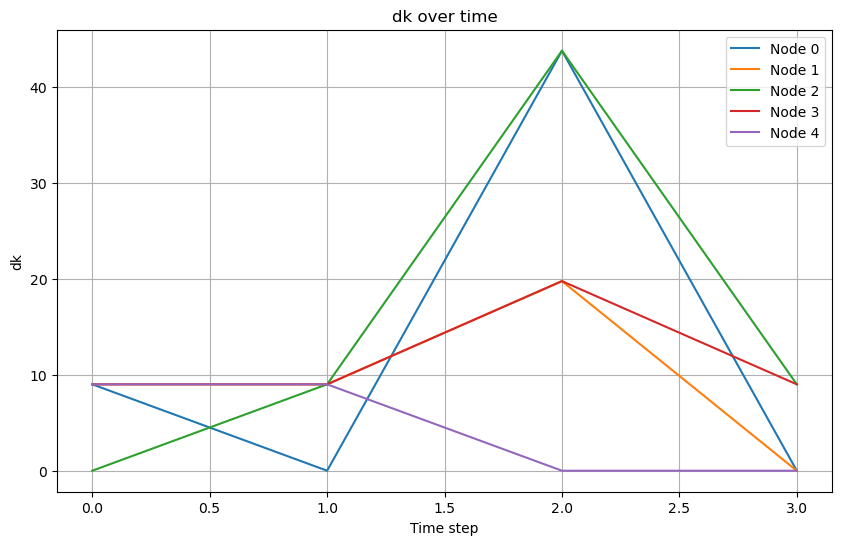

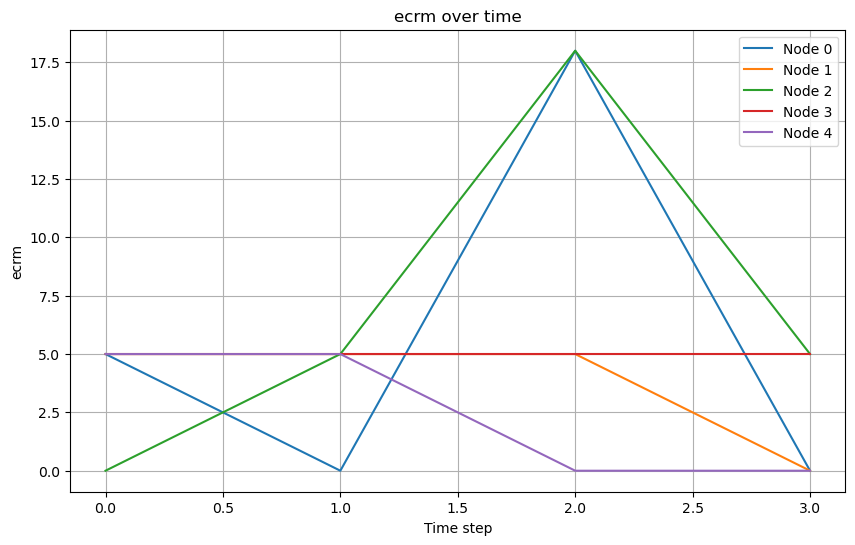

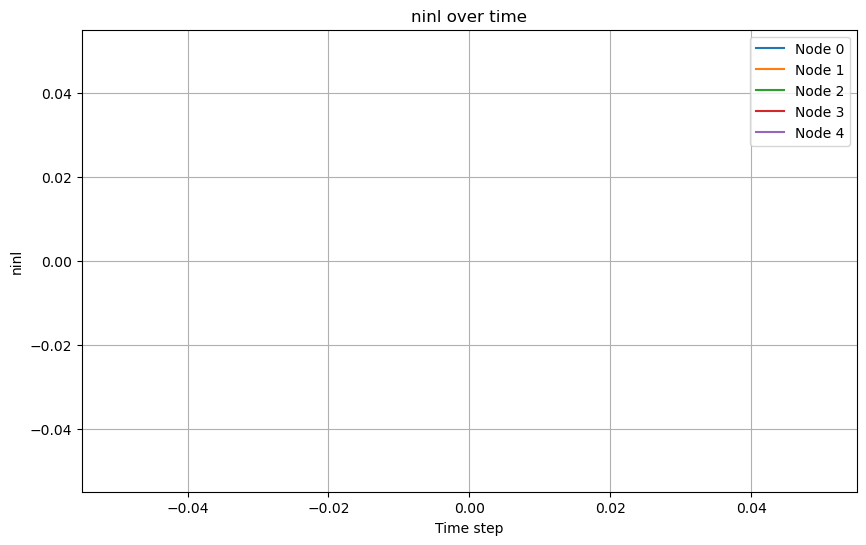

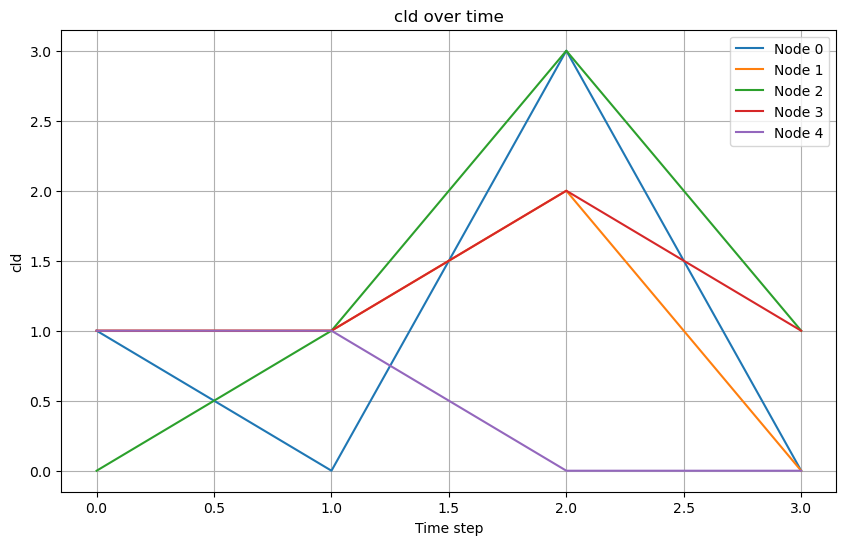

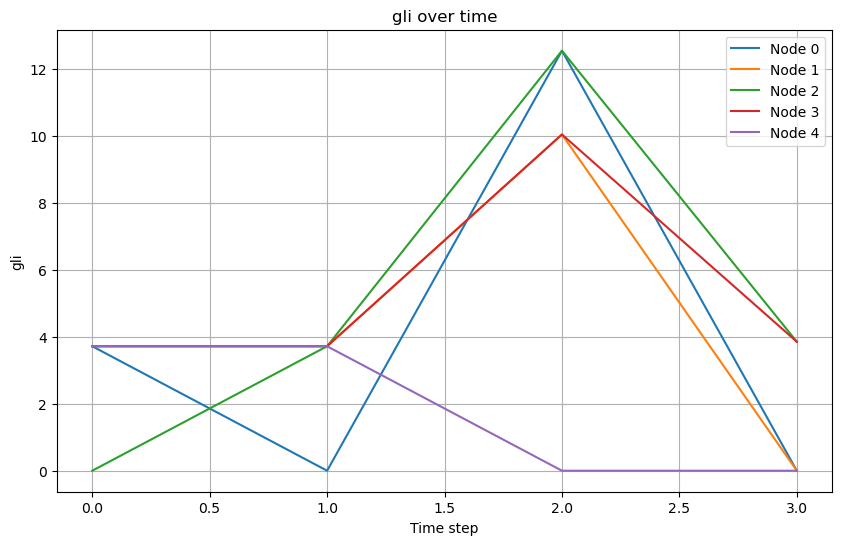

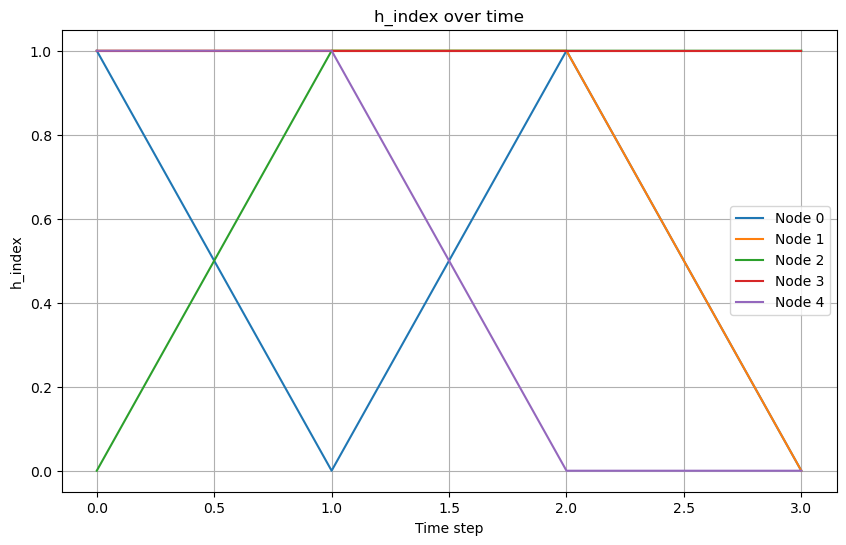

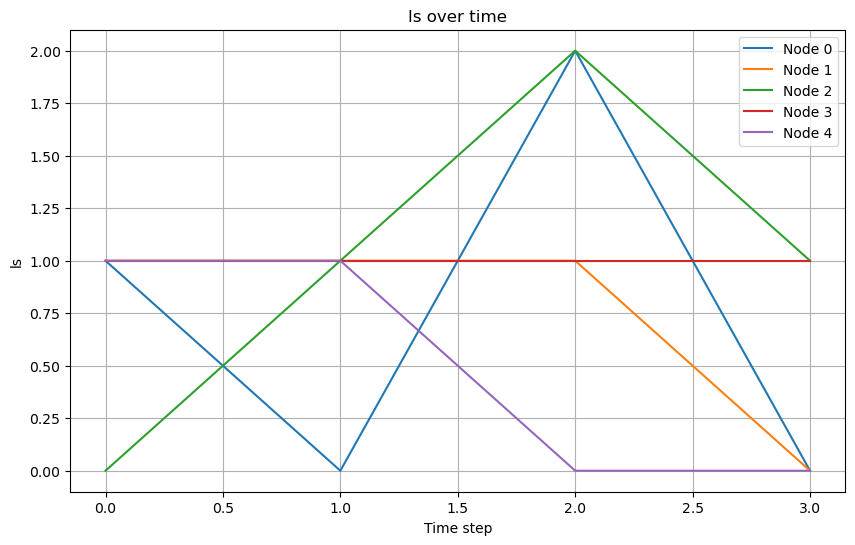

In [11]:
# Extract metrics for plotting
metric_names = metrics_over_time[0].keys()  # Assuming all snapshots have the same metrics
time_steps = range(len(metrics_over_time))

# Plot each metric over time
for metric in metric_names:
    plt.figure(figsize=(10, 6))
    for node in snapshots[0].nodes():
        values = [metrics_over_time[t][metric][node] for t in time_steps]
        plt.plot(time_steps, values, label=f"Node {node}")
    plt.title(f"{metric} over time")
    plt.xlabel("Time step")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)
    plt.show()

In [12]:
metrics = get_metric_names()
metrics.remove("tgc")  # Remove TGC for static graph

results = compute_metric(snapshots, "igc")
results = compute_metric(snapshots, "igc", parallel=True, processes=4)
results = compute_metric(snapshots, "tgc")
results = compute_metric(snapshots, "tgc", parallel=True, processes=4)

results = compute_metrics(snapshots, metrics)
results = compute_metrics(snapshots, metrics, parallel=True, processes=4)

You should maybe not enable parallel processing for graphs with < 500 nodes.
You should maybe not enable parallel processing for graphs with < 500 nodes.
Graph at index 0 is not connected; skipping avg_shortest_path and metrics based on it (['lgc', 'mcgm', 'ninl', 'ninl_layer0'])
Graph at index 1 is not connected; skipping avg_shortest_path and metrics based on it (['lgc', 'mcgm', 'ninl', 'ninl_layer0'])
Graph at index 2 is not connected; skipping avg_shortest_path and metrics based on it (['lgc', 'mcgm', 'ninl', 'ninl_layer0'])
Graph at index 3 is not connected; skipping avg_shortest_path and metrics based on it (['lgc', 'mcgm', 'ninl', 'ninl_layer0'])
Graph at index 0 is not connected; skipping avg_shortest_path and metrics based on it (['lgc', 'mcgm', 'ninl', 'ninl_layer0'])
Graph at index 1 is not connected; skipping avg_shortest_path and metrics based on it (['lgc', 'mcgm', 'ninl', 'ninl_layer0'])
Graph at index 2 is not connected; skipping avg_shortest_path and metrics based on i

In [15]:
G = nx.erdos_renyi_graph(100, 0.3, seed=42)

metrics = get_metric_names()
metrics.remove("tgc")  # Remove TGC for static graph

results = compute_metric(G, "igc")
results = compute_metric(G, "igc", parallel=True, processes=4)
#results = compute_metric(G, "tgc")
#results = compute_metric(G, "tgc", parallel=True, processes=4)

results = compute_metrics(G, metrics)
results = compute_metrics(G, metrics, parallel=True, processes=4)